In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [33]:
dataframe = pd.read_csv("../logs/qwen3_0.6b_base_instruct_20260309_221123.csv")

In [34]:
dataframe.describe()

,Epochs,Total Tokens Seen,Training Loss,Validation Loss
count,6.000000,6.00000,6.000000,6.000000
mean,0.524425,8101.50000,0.875618,1.117769
std,0.381086,5885.48478,1.401849,1.289501
min,0.000000,165.00000,0.220547,0.525112
25%,0.269397,4034.75000,0.224812,0.532819
50%,0.538793,8268.00000,0.270486,0.598145
75%,0.808190,12524.50000,0.485122,0.696010
max,0.991379,15341.00000,3.725938,3.745536


In [35]:
def plot_losses(epochs_seen, examples_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Total Tokens Seen")

    fig.tight_layout()  # Adjust layout to make room
    
    plt.show()

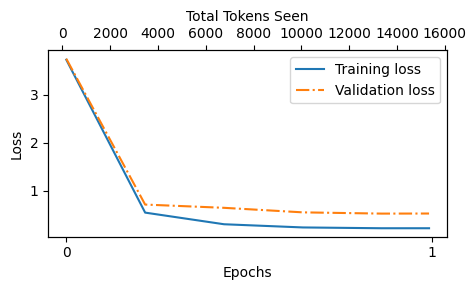

In [36]:
plot_losses(dataframe["Epochs"].values, dataframe["Total Tokens Seen"], dataframe["Training Loss"], dataframe["Validation Loss"])

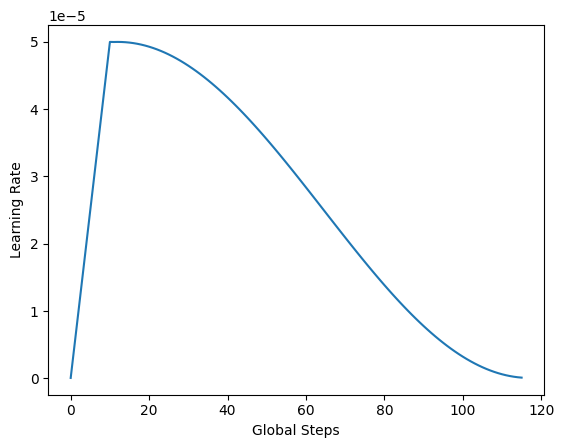

In [32]:
df_learning_rate = pd.read_csv("../logs/qwen3_0.6b_base_instruct_learning_rate_20260309_221123.csv")
clean_lr = df_learning_rate["Learning Rate"].str.strip("[]").astype(float)

plt.ylabel("Learning Rate")
plt.xlabel("Global Steps")
plt.plot(df_learning_rate["Global Steps"], clean_lr)
plt.show()